# Portable result notebook

This notebook reads the released source data from the directory next to the
repository. Set the `WALKABILITY_SOURCE_DATA` environment variable to use a
different location. Outputs are written to `outputs/figures`.


In [ ]:
from pathlib import Path
import os

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / "pyproject.toml").exists():
    REPO_ROOT = WORKING_DIR
elif WORKING_DIR.name == "Result replication" and (WORKING_DIR.parent / "pyproject.toml").exists():
    REPO_ROOT = WORKING_DIR.parent
else:
    raise RuntimeError("Run this notebook from the repository root or Result replication directory")

SOURCE_DATA_DIR = Path(os.environ.get(
    "WALKABILITY_SOURCE_DATA",
    REPO_ROOT.parent / "source data",
)).resolve()
OUTPUT_DIR = (REPO_ROOT / "outputs" / "figures").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not SOURCE_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Source data not found at {SOURCE_DATA_DIR}. Place it next to the repository "
        "or set WALKABILITY_SOURCE_DATA to its location."
    )

print(f"Source data: {SOURCE_DATA_DIR}")
print(f"Figure output: {OUTPUT_DIR}")


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings

warnings.filterwarnings("ignore")

city_mapping = [
    ('北京市', 'Beijing'),
    ('石家庄市', 'Shijiazhuang'),
    ('苏州市', 'Suzhou'),
    ('东莞市', 'Dongguan')
]

custom_colors = [
    '#A50026', '#D8382D', '#F47C4A', '#FDBE70', '#FEEDA1',
    '#E9F5A1', '#B6E076', '#73C364', '#289B51', '#006837'
]
jet = colors.LinearSegmentedColormap.from_list('custom_sequential', custom_colors)
cNorm = colors.Normalize(vmin=0, vmax=1)

print("Reading road network data...")
roads_data = {}
for City_name, city_name in city_mapping:
    roads_file = SOURCE_DATA_DIR / 'street-level walkability' / f'{city_name}_streets.json'
    roads_shp = gpd.read_file(roads_file)
    roads_shp = roads_shp.to_crs("EPSG:4793")
    roads_data[City_name] = roads_shp
    print(f"Finished loading data for {city_name}!")

print("Plotting SWI (1x4 grid)...")
fig_swi, axes_swi = plt.subplots(1, 4, figsize=(32, 8))

for i, (City_name, city_name) in enumerate(city_mapping):
    ax = axes_swi[i]
    roads = roads_data[City_name].copy()

    roads['color'] = roads['SWI'].apply(lambda x: jet(cNorm(x)))
    roads.plot(ax=ax, color=roads['color'], linewidth=1.1, zorder=2)

    ax.axis('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Four_Cities_SWI.png', bbox_inches='tight', dpi=300)
plt.show()

print("Plotting DWI (1x4 grid)...")
fig_dwi, axes_dwi = plt.subplots(1, 4, figsize=(32, 8))

for i, (City_name, city_name) in enumerate(city_mapping):
    ax = axes_dwi[i]
    roads = roads_data[City_name].copy()

    roads = roads.sort_values(by='DWI', ascending=False)
    roads['color'] = roads['DWI'].apply(lambda x: jet(cNorm(x)))
    roads.plot(ax=ax, color=roads['color'], linewidth=1.1, zorder=2)

    ax.axis('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Four_Cities_DWI.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings

warnings.filterwarnings("ignore")
city_df = pd.read_csv(SOURCE_DATA_DIR / "City_Morphology_Correlation.csv")

custom_colors = [
    '#A50026', '#D8382D', '#F47C4A', '#FDBE70', '#FEEDA1',
    '#E9F5A1', '#B6E076', '#73C364', '#289B51', '#006837'
]
palette = colors.LinearSegmentedColormap.from_list('custom_sequential', custom_colors)

for column in ['PE_swi', 'PE_dwi']:
    values = city_df[column]
    norm = colors.Normalize(vmin=values.min(), vmax=values.max())
    population = city_df['residents (ten thousand)']
    point_size = 30 + 470 * (population - population.min()) / (population.max() - population.min())

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        city_df['longitude'], city_df['Latitude'],
        c=values, cmap=palette, norm=norm, s=point_size,
        alpha=0.75, edgecolor='white', linewidth=0.4,
    )
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f"Experienced walkability across 82 cities: {column}")
    fig.colorbar(scatter, ax=ax, label=column)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"Figure1_city_experience_{column}.png", bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

city_df = pd.read_csv(
    SOURCE_DATA_DIR / 'City_Morphology_Correlation.csv')

df_pos = city_df[city_df['corr_PE_swi_dwi'] > 0]
df_neg = city_df[city_df['corr_PE_swi_dwi'] < 0]

pos_ratio = len(df_pos) / len(city_df) * 100
neg_ratio = len(df_neg) / len(city_df) * 100

pos_cities = df_pos['city_en'].tolist()
neg_cities = df_neg['city_en'].tolist()

print(f"Proportion of cities > 0: {pos_ratio:.2f}%")
print(f"Cities > 0: {pos_cities}\n")

print(f"Proportion of cities < 0: {neg_ratio:.2f}%")
print(f"Cities < 0: {neg_cities}\n")

city_df_sorted = city_df.sort_values(by='corr_PE_swi_dwi', ascending=False).reset_index(drop=True)

max_abs = city_df_sorted['corr_PE_swi_dwi'].abs().max()


def get_color(val, max_val):
    if val == 0:
        return 'gray'

    intensity = 0.3 + 0.7 * (abs(val) / max_val)

    if val > 0:
        return plt.cm.Reds(intensity)
    else:
        return plt.cm.Blues(intensity)


colors = [get_color(val, max_abs) for val in city_df_sorted['corr_PE_swi_dwi']]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(5, 6))

ax.hlines(y=city_df_sorted.index, xmin=0, xmax=city_df_sorted['corr_PE_swi_dwi'],
          colors=colors, linewidth=2)

ax.scatter(city_df_sorted['corr_PE_swi_dwi'], city_df_sorted.index, color=colors, s=8, zorder=3)

ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.spines['top'].set_visible(True)
ax.spines['top'].set_linewidth(1.5)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.tick_params(axis='x', labelsize=17)

ax.set_yticks([])
ax.set_ylabel('')

ax.invert_yaxis()

ax.set_xlim([-0.45, 0.45])
ax.set_xticks([-0.45, -0.3, -0.15, 0, 0.15, 0.3, 0.45])

ax.axvline(0, color='black', linewidth=1.5, zorder=1)

ax.set_xlabel(r"$\rho(\mathit{PE}_{\mathit{SWI}}, \mathit{PE}_{\mathit{DWI}})$", fontsize=17, fontweight='bold',
              labelpad=15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'corr_PE_swi_dwi.svg', bbox_inches='tight')
plt.show()

## Authors' executed workstation record

The following cells retain the original workstation paths, execution counts and outputs. Keeping the executed code beside its output makes the provenance of the displayed results directly inspectable on GitHub. Use the portable cells above for execution on another computer.


Reading road network data...
Finished loading data for Beijing!
Finished loading data for Shijiazhuang!
Finished loading data for Suzhou!
Finished loading data for Dongguan!
Plotting SWI (1x4 grid)...


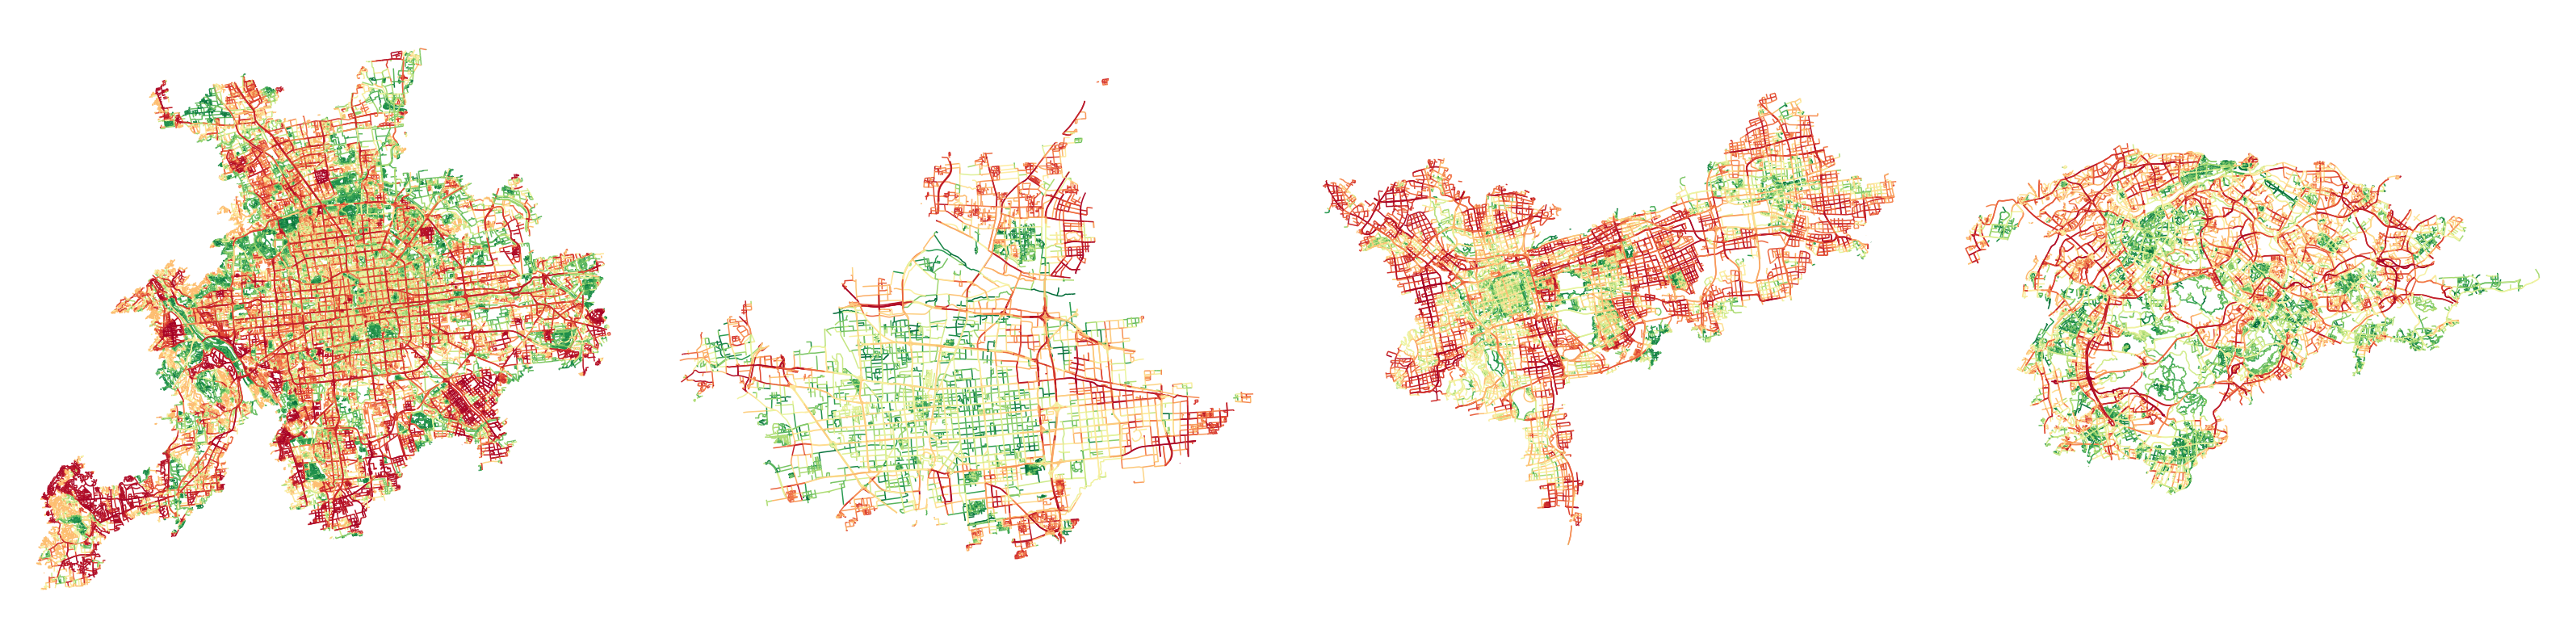

Plotting DWI (1x4 grid)...


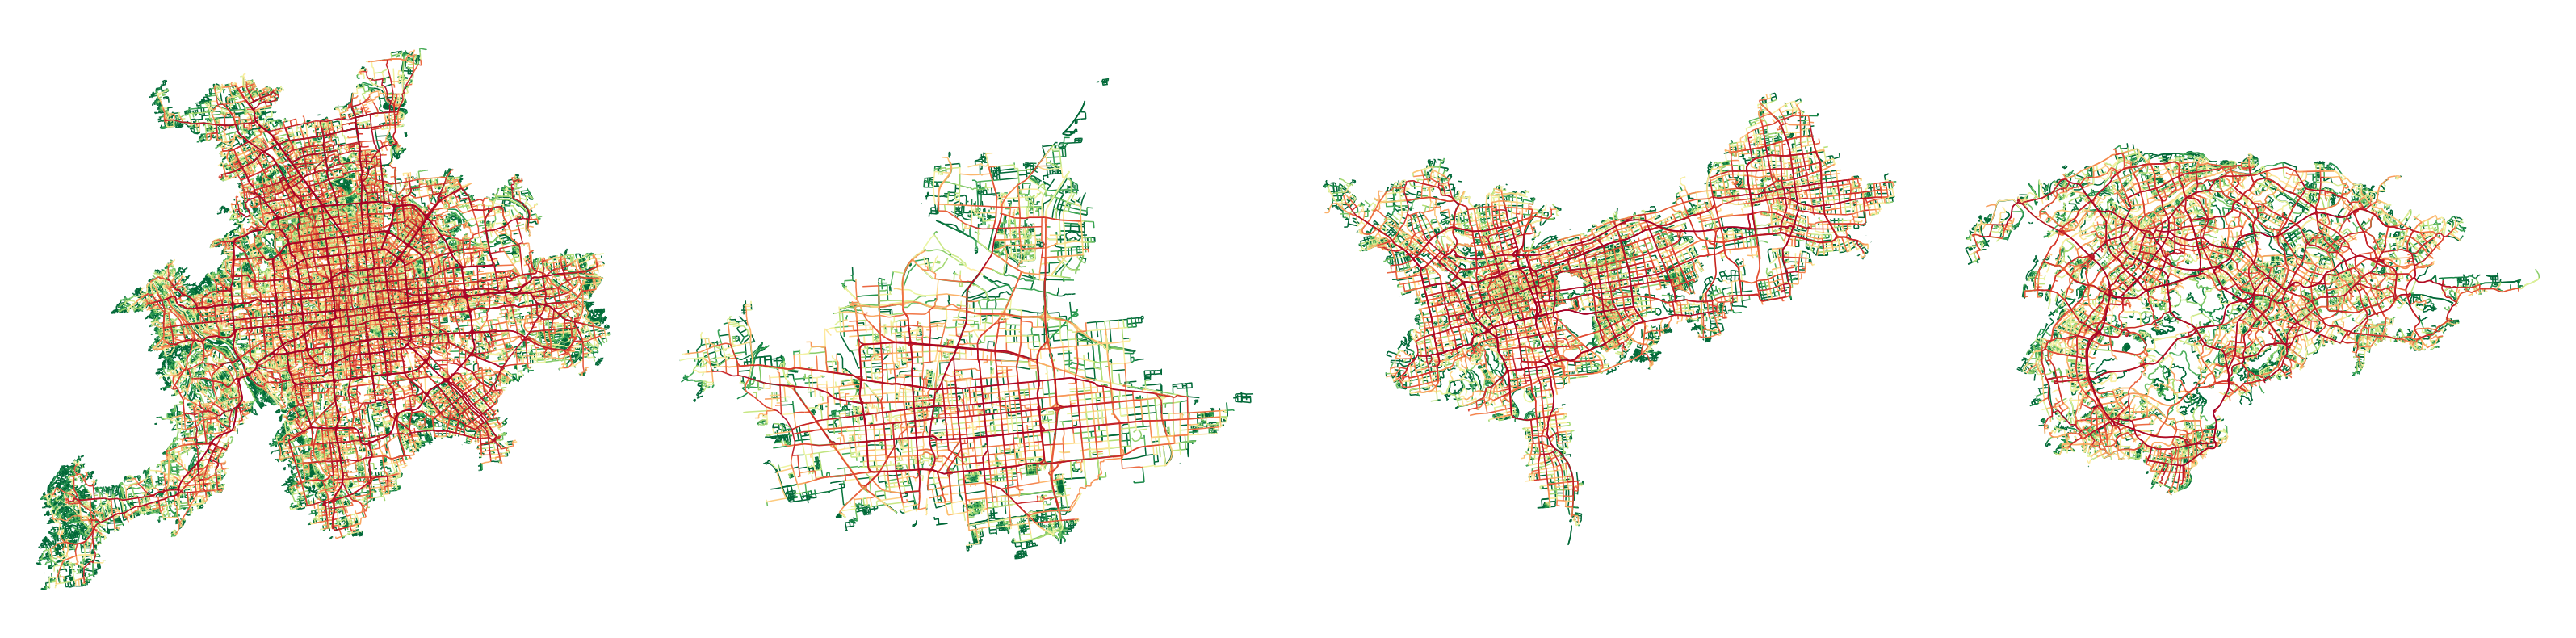

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings

warnings.filterwarnings("ignore")

city_mapping = [
    ('北京市', 'Beijing'),
    ('石家庄市', 'Shijiazhuang'),
    ('苏州市', 'Suzhou'),
    ('东莞市', 'Dongguan')
]

custom_colors = [
    '#A50026', '#D8382D', '#F47C4A', '#FDBE70', '#FEEDA1',
    '#E9F5A1', '#B6E076', '#73C364', '#289B51', '#006837'
]
jet = colors.LinearSegmentedColormap.from_list('custom_sequential', custom_colors)
cNorm = colors.Normalize(vmin=0, vmax=1)

print("Reading road network data...")
roads_data = {}
for City_name, city_name in city_mapping:
    roads_file = f'E:/experienced walkability across urban forms/Code and Data/source data/street-level walkability/{city_name}_streets.json'
    roads_shp = gpd.read_file(roads_file)
    roads_shp = roads_shp.to_crs("EPSG:4793")
    roads_data[City_name] = roads_shp
    print(f"Finished loading data for {city_name}!")

print("Plotting SWI (1x4 grid)...")
fig_swi, axes_swi = plt.subplots(1, 4, figsize=(32, 8))

for i, (City_name, city_name) in enumerate(city_mapping):
    ax = axes_swi[i]
    roads = roads_data[City_name].copy()

    roads['color'] = roads['SWI'].apply(lambda x: jet(cNorm(x)))
    roads.plot(ax=ax, color=roads['color'], linewidth=1.1, zorder=2)

    ax.axis('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig('F:/Four_Cities_SWI.png', bbox_inches='tight', dpi=300)
plt.show()

print("Plotting DWI (1x4 grid)...")
fig_dwi, axes_dwi = plt.subplots(1, 4, figsize=(32, 8))

for i, (City_name, city_name) in enumerate(city_mapping):
    ax = axes_dwi[i]
    roads = roads_data[City_name].copy()

    roads = roads.sort_values(by='DWI', ascending=False)
    roads['color'] = roads['DWI'].apply(lambda x: jet(cNorm(x)))
    roads.plot(ax=ax, color=roads['color'], linewidth=1.1, zorder=2)

    ax.axis('equal')
    ax.axis('off')

plt.tight_layout()
plt.savefig('F:/Four_Cities_DWI.png', bbox_inches='tight', dpi=300)
plt.show()

Generating plot for PE_swi...


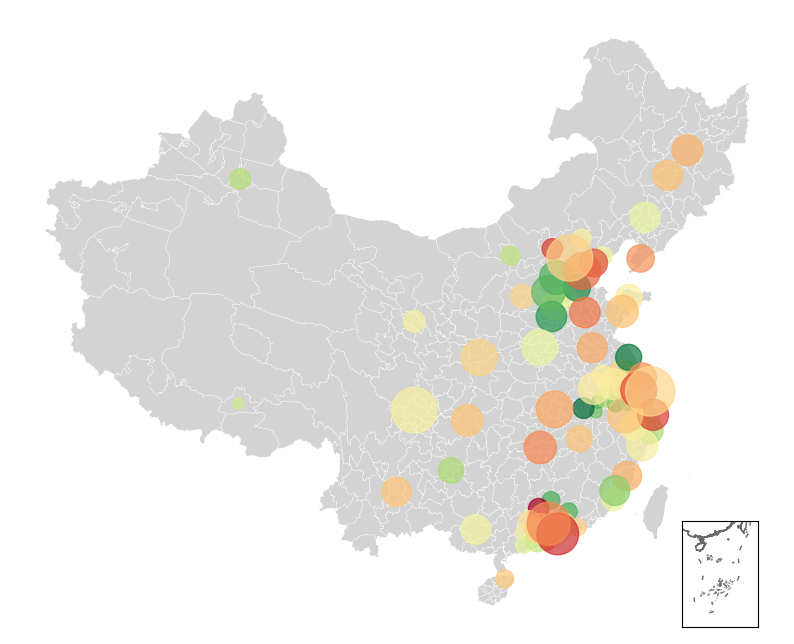

Generating plot for PE_dwi...


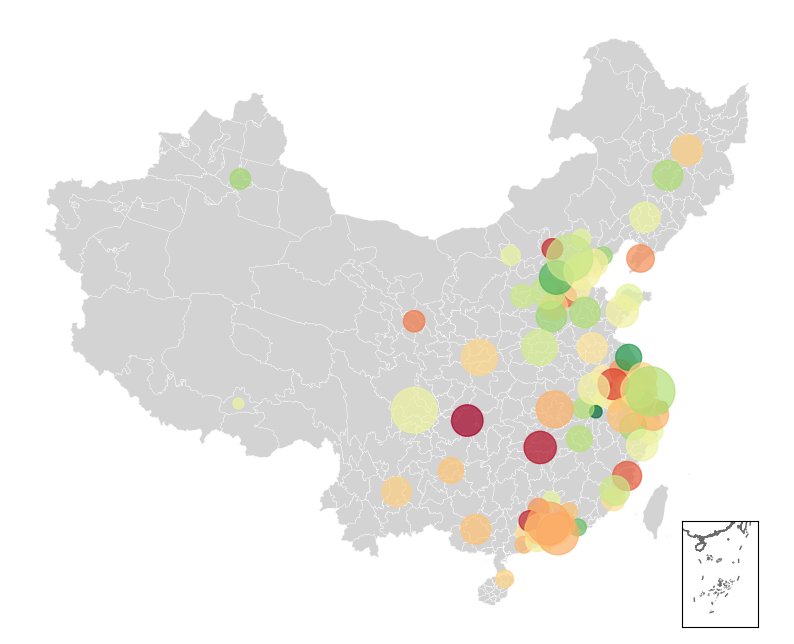

In [2]:
import pandas as pd
import numpy as np
import geopandas
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings

warnings.filterwarnings("ignore")

city_df = pd.read_csv(
    'E:\experienced walkability across urban forms\Code and Data\source data\City_Morphology_Correlation.csv')

p1 = pyproj.Proj('epsg:4793')
Prefecture_shp = geopandas.read_file('E:/experienced walkability across urban forms/Prefecture City.shp')
Prefecture_shp = Prefecture_shp.to_crs('epsg:4793')
guojie_shp = geopandas.read_file('E:/experienced walkability across urban forms/guojie.shp')
guojie_shp = guojie_shp.to_crs('epsg:4793')

Prefecture_shp['x'] = np.around(Prefecture_shp.geometry.centroid.x)
Prefecture_shp['y'] = np.around(Prefecture_shp.geometry.centroid.y)
city_centroid_dict = dict(zip(Prefecture_shp["city_name"], zip(Prefecture_shp["x"], Prefecture_shp["y"])))
all_prefecture_city = Prefecture_shp['city_name'].values
Prefecture_shp.index = all_prefecture_city

Prefecture_shp['PE_swi'] = -1
Prefecture_shp['PE_dwi'] = -1
Prefecture_shp['pop'] = -1

for dex, city_i in city_df.iterrows():
    City_name = city_i['city_cn']
    pop = city_i['residents (ten thousand)']
    real_SWI_PE = city_i['PE_swi']
    real_DWI_PE = city_i['PE_dwi']
    Prefecture_shp.loc[City_name, 'pop'] = pop
    Prefecture_shp.loc[City_name, 'PE_swi'] = real_SWI_PE
    Prefecture_shp.loc[City_name, 'PE_dwi'] = real_DWI_PE

target_columns = ['PE_swi', 'PE_dwi']

custom_colors = [
    '#A50026', '#D8382D', '#F47C4A', '#FDBE70', '#FEEDA1',
    '#E9F5A1', '#B6E076', '#73C364', '#289B51', '#006837']
jet = colors.LinearSegmentedColormap.from_list('custom_sequential', custom_colors)

for column in target_columns:
    print(f"Generating plot for {column}...")

    Prefecture_shp_withdata = Prefecture_shp[Prefecture_shp[column] >= 0].copy()
    Prefecture_shp_nodata = Prefecture_shp[Prefecture_shp[column] < 0].copy()

    min_set = Prefecture_shp_withdata[column].min()
    max_set = Prefecture_shp_withdata[column].max()
    cNorm = colors.Normalize(vmin=min_set, vmax=max_set)

    Prefecture_shp_withdata['color'] = Prefecture_shp_withdata[column].apply(lambda x: jet(cNorm(x)))
    Prefecture_shp_withdata['size'] = (
                                              (Prefecture_shp_withdata['pop'] - Prefecture_shp_withdata[
                                                  'pop'].min()) /
                                              (Prefecture_shp_withdata['pop'].max() - Prefecture_shp_withdata[
                                                  'pop'].min()) + 0.05
                                      ) * 1200

    Prefecture_shp_withdata = Prefecture_shp_withdata.sort_values(by='pop', ascending=True)
    Prefecture_shp_nodata['color'] = '#EAEAEA'

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    Prefecture_shp.plot(ax=ax, facecolor='#D3D3D3', linewidth=0.2, edgecolor='white', zorder=1)

    ax.scatter(Prefecture_shp_withdata['x'], Prefecture_shp_withdata['y'],
               color=Prefecture_shp_withdata['color'], s=Prefecture_shp_withdata['size'], alpha=0.7, zorder=2)

    axins = inset_axes(ax, width="15%", height="17%", loc=4)
    guojie_shp.plot(ax=axins, facecolor='White', edgecolor='dimgray', alpha=1, linewidth=1.0, zorder=1)
    axins.set_xlim([0.2e6, 2.2e6])
    axins.set_ylim([0e6, 2.8e6])

    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    axins.set_xticks([])
    axins.set_yticks([])

    plt.savefig(f'F:/Prefecture_shp_{column}.png', bbox_inches='tight')
    plt.show()

    plt.close(fig)


Proportion of cities > 0: 67.07%
Cities > 0: ['Hefei', 'Guangzhou', 'Beijing', 'Chengdu', 'Chongqing', 'Shanghai', 'Shenzhen', 'Suzhou', 'Hangzhou', 'Tianjin', 'Nanjing', 'Changchun', 'Ningbo', 'Changsha', 'Wuxi', 'Dongguan', 'Foshan', 'Quanzhou', 'Kunming', 'Qingdao', 'Nanchang', 'Fuzhou', 'Nantong', 'Wenzhou', 'Nanning', 'Wuhan', 'Tangshan', 'Taiyuan', 'Shenyang', 'Harbin', 'Taizhou (Zhejiang)', 'Changzhou', 'Guiyang', 'Dalian', 'Zhongshan', 'Langfang', 'Yangzhou', 'Huizhou', 'Jinan', 'Zhangjiakou', 'Qinhuangdao', 'Zhenjiang', 'Hengshui', 'Wuhu', 'Jiangmen', 'Qingyuan', 'Chengde', 'Heyuan', 'Zhaoqing', 'Zhuhai', 'Shaoguan', 'Zhoushan', 'Yunfu', 'Shanwei', 'Tongling']

Proportion of cities < 0: 32.93%
Cities < 0: ["Xi'an", 'Zhengzhou', 'Shijiazhuang', 'Urumqi', 'Xuzhou', 'Jinhua', 'Baoding', 'Hohhot', 'Handan', 'Lanzhou', 'Jiaxing', 'Shaoxing', 'Cangzhou', 'Yancheng', 'Xiamen', 'Xingtai', 'Taizhou (Jiangsu)', 'Yantai', 'Huzhou', 'Haikou', 'Anqing', 'Lhasa', 'Xuancheng', 'Chuzhou', 'Ya

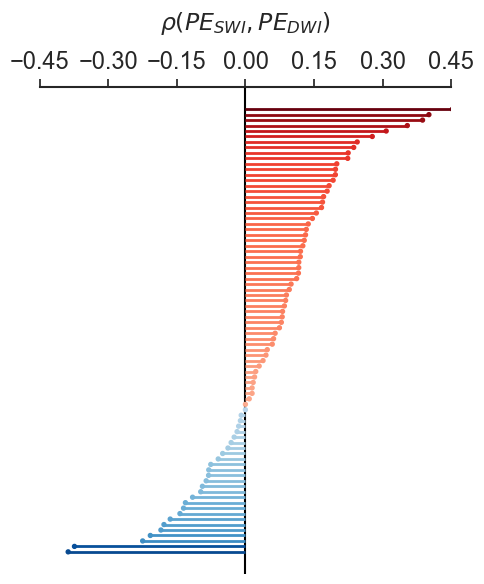

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

city_df = pd.read_csv(
    r'E:\experienced walkability across urban forms\Code and Data\source data\City_Morphology_Correlation.csv')

df_pos = city_df[city_df['corr_PE_swi_dwi'] > 0]
df_neg = city_df[city_df['corr_PE_swi_dwi'] < 0]

pos_ratio = len(df_pos) / len(city_df) * 100
neg_ratio = len(df_neg) / len(city_df) * 100

pos_cities = df_pos['city_en'].tolist()
neg_cities = df_neg['city_en'].tolist()

print(f"Proportion of cities > 0: {pos_ratio:.2f}%")
print(f"Cities > 0: {pos_cities}\n")

print(f"Proportion of cities < 0: {neg_ratio:.2f}%")
print(f"Cities < 0: {neg_cities}\n")

city_df_sorted = city_df.sort_values(by='corr_PE_swi_dwi', ascending=False).reset_index(drop=True)

max_abs = city_df_sorted['corr_PE_swi_dwi'].abs().max()


def get_color(val, max_val):
    if val == 0:
        return 'gray'

    intensity = 0.3 + 0.7 * (abs(val) / max_val)

    if val > 0:
        return plt.cm.Reds(intensity)
    else:
        return plt.cm.Blues(intensity)


colors = [get_color(val, max_abs) for val in city_df_sorted['corr_PE_swi_dwi']]

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(5, 6))

ax.hlines(y=city_df_sorted.index, xmin=0, xmax=city_df_sorted['corr_PE_swi_dwi'],
          colors=colors, linewidth=2)

ax.scatter(city_df_sorted['corr_PE_swi_dwi'], city_df_sorted.index, color=colors, s=8, zorder=3)

ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.spines['top'].set_visible(True)
ax.spines['top'].set_linewidth(1.5)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.tick_params(axis='x', labelsize=17)

ax.set_yticks([])
ax.set_ylabel('')

ax.invert_yaxis()

ax.set_xlim([-0.45, 0.45])
ax.set_xticks([-0.45, -0.3, -0.15, 0, 0.15, 0.3, 0.45])

ax.axvline(0, color='black', linewidth=1.5, zorder=1)

ax.set_xlabel(r"$\rho(\mathit{PE}_{\mathit{SWI}}, \mathit{PE}_{\mathit{DWI}})$", fontsize=17, fontweight='bold',
              labelpad=15)

plt.tight_layout()
plt.savefig('F:/corr_PE_swi_dwi.svg', bbox_inches='tight')
plt.show()